# 抗体言語モデル埋め込み空間 UMAP 解析

このノートブックは **UMAP 可視化のみ** を行います。

事前に以下のスクリプトを実行しておく必要があります:

```bash
# 1. データダウンロード・前処理・CDR3特定
mamba run -n ablm python scripts/01_download_data.py --n 10000

# 2. 埋め込み生成（全モデル）
mamba run -n ablm python scripts/02_generate_embeddings.py
```

上記が完了すると `data/` フォルダに以下のファイルが生成されます:

| ファイル | 説明 |
|---|---|
| `sequences_processed.csv` | 前処理済み配列（v_family など） |
| `antiberty_seq_vecs.npy` | AntiBERTy シーケンスレベル (N, 512) |
| `antiberty_cdr3_vecs.npy` | AntiBERTy CDR-H3 レベル (N, 512) |
| `ablang_seq_vecs.npy` | AbLang シーケンスレベル (N, 768) |
| `ablang_cdr3_vecs.npy` | AbLang CDR-H3 レベル (N, 768) |
| `ablang2_seq_vecs.npy` | AbLang-2 **VH+VL ペア入力** シーケンスレベル (N, D) |
| `ablang2_cdr3_vecs.npy` | AbLang-2 **VH+VL ペア入力** CDR-H3 レベル (N, D) |
| `ablang2_heavy_seq_vecs.npy` | AbLang-2 **VH 単独入力** シーケンスレベル (N, D) |
| `ablang2_heavy_cdr3_vecs.npy` | AbLang-2 **VH 単独入力** CDR-H3 レベル (N, D) |

AbLang-2 の入力トークン形式:
- **Paired**: `< VH残基... > | < VL残基... >`
- **Heavy-only**: `< VH残基... > |`（VL なし・同じモデル重みを使用）

## 0. セットアップ

In [3]:
import warnings
from pathlib import Path

import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

# ── 必須ファイルの存在確認 ──
required_files = [
    DATA_DIR / "sequences_processed.csv",
    DATA_DIR / "antiberty_seq_vecs.npy",
    DATA_DIR / "antiberty_cdr3_vecs.npy",
    DATA_DIR / "ablang_seq_vecs.npy",
    DATA_DIR / "ablang_cdr3_vecs.npy",
    DATA_DIR / "ablang2_seq_vecs.npy",
    DATA_DIR / "ablang2_cdr3_vecs.npy",
    DATA_DIR / "ablang2_heavy_seq_vecs.npy",
    DATA_DIR / "ablang2_heavy_cdr3_vecs.npy",
]
missing = [str(f) for f in required_files if not f.exists()]
if missing:
    raise FileNotFoundError(
        f"以下のファイルが見つかりません。先にスクリプトを実行してください:\n"
        + "\n".join(f"  {m}" for m in missing)
    )
print("全ファイルを確認しました")

全ファイルを確認しました


## 1. データと埋め込みベクトルの読み込み

In [4]:
df = pd.read_csv(DATA_DIR / "sequences_processed.csv")
v_families = df["v_family"].tolist()

vectors = {
    ("AntiBERTy", "Sequence"): np.load(DATA_DIR / "antiberty_seq_vecs.npy"),
    ("AntiBERTy", "CDR-H3"):   np.load(DATA_DIR / "antiberty_cdr3_vecs.npy"),
    ("AbLang",    "Sequence"): np.load(DATA_DIR / "ablang_seq_vecs.npy"),
    ("AbLang",    "CDR-H3"):   np.load(DATA_DIR / "ablang_cdr3_vecs.npy"),
    ("AbLang-2 (paired)",  "Sequence"): np.load(DATA_DIR / "ablang2_seq_vecs.npy"),
    ("AbLang-2 (paired)",  "CDR-H3"):   np.load(DATA_DIR / "ablang2_cdr3_vecs.npy"),
    ("AbLang-2 (heavy)",   "Sequence"): np.load(DATA_DIR / "ablang2_heavy_seq_vecs.npy"),
    ("AbLang-2 (heavy)",   "CDR-H3"):   np.load(DATA_DIR / "ablang2_heavy_cdr3_vecs.npy"),
    ("ESM-2",    "Sequence"): np.load(DATA_DIR / "esm2_seq_vecs.npy"),
    ("ESM-2",    "CDR-H3"):   np.load(DATA_DIR / "esm2_cdr3_vecs.npy"),
    ("ProGen-2", "Sequence"): np.load(DATA_DIR / "progen2_seq_vecs.npy"),
    ("ProGen-2", "CDR-H3"):   np.load(DATA_DIR / "progen2_cdr3_vecs.npy"),
}

print(f"配列数: {len(df)}")
print("V遺伝子ファミリー分布:")
print(df["v_family"].value_counts().sort_index().to_string())
print("各ベクトルのサイズ:")
for (model, level), vecs in vectors.items():
    print(f"  {model:20s} [{level:8s}]: {vecs.shape}")

配列数: 8626
V遺伝子ファミリー分布:
v_family
IGHV1    1428
IGHV2    1428
IGHV3    1428
IGHV4    1428
IGHV5    1428
IGHV6     637
IGHV7     849
各ベクトルのサイズ:
  AntiBERTy            [Sequence]: (8626, 512)
  AntiBERTy            [CDR-H3  ]: (8626, 512)
  AbLang               [Sequence]: (8626, 768)
  AbLang               [CDR-H3  ]: (8626, 768)
  AbLang-2 (paired)    [Sequence]: (8626, 480)
  AbLang-2 (paired)    [CDR-H3  ]: (8626, 480)
  AbLang-2 (heavy)     [Sequence]: (8626, 480)
  AbLang-2 (heavy)     [CDR-H3  ]: (8626, 480)
  ESM-2                [Sequence]: (8626, 1280)
  ESM-2                [CDR-H3  ]: (8626, 1280)
  ProGen-2             [Sequence]: (8626, 1536)
  ProGen-2             [CDR-H3  ]: (8626, 1536)


## 2. 色設定（Okabe-Ito パレット）

In [5]:
# Okabe-Ito 色覚多様性対応パレット（7色）
OKABE_ITO_7 = [
    "#E69F00",  # orange     → IGHV1
    "#56B4E9",  # sky blue   → IGHV2
    "#009E73",  # green      → IGHV3
    "#F0E442",  # yellow     → IGHV4
    "#0072B2",  # blue       → IGHV5
    "#D55E00",  # vermillion → IGHV6
    "#CC79A7",  # pink       → IGHV7
]

unique_families = sorted(set(v_families))
family_color = {
    fam: OKABE_ITO_7[i % len(OKABE_ITO_7)]
    for i, fam in enumerate(unique_families)
}
point_colors = [family_color[f] for f in v_families]
legend_handles = [
    mpatches.Patch(color=family_color[fam], label=fam)
    for fam in unique_families
]

print("色マッピング:")
for fam, col in family_color.items():
    n = v_families.count(fam)
    print(f"  {fam}: {col}  ({n} 配列)")

色マッピング:
  IGHV1: #E69F00  (1428 配列)
  IGHV2: #56B4E9  (1428 配列)
  IGHV3: #009E73  (1428 配列)
  IGHV4: #F0E442  (1428 配列)
  IGHV5: #0072B2  (1428 配列)
  IGHV6: #D55E00  (637 配列)
  IGHV7: #CC79A7  (849 配列)


## 3. UMAP の計算（8パネル分）

- `n_neighbors=15`, `min_dist=0.1`, `metric='cosine'`

In [6]:
def run_umap(
    vecs: np.ndarray,
    n_neighbors: int = 15,
    min_dist: float = 0.1,
    metric: str = "cosine",
    random_state: int = RANDOM_STATE,
) -> np.ndarray:
    """(N, D) → (N, 2) に UMAP 圧縮する。"""
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
        n_components=2,
        low_memory=False,
    )
    return reducer.fit_transform(vecs)


print("UMAP を計算中（6パネル分）...")
umap_coords: dict[tuple[str, str], np.ndarray] = {}
for (model_name, level), vecs in vectors.items():
    print(f"  {model_name} [{level}] shape={vecs.shape} ...")
    umap_coords[(model_name, level)] = run_umap(vecs)
print("\nUMAP 計算完了")

UMAP を計算中（6パネル分）...
  AntiBERTy [Sequence] shape=(8626, 512) ...


  AntiBERTy [CDR-H3] shape=(8626, 512) ...
  AbLang [Sequence] shape=(8626, 768) ...
  AbLang [CDR-H3] shape=(8626, 768) ...
  AbLang-2 (paired) [Sequence] shape=(8626, 480) ...
  AbLang-2 (paired) [CDR-H3] shape=(8626, 480) ...
  AbLang-2 (heavy) [Sequence] shape=(8626, 480) ...
  AbLang-2 (heavy) [CDR-H3] shape=(8626, 480) ...
  ESM-2 [Sequence] shape=(8626, 1280) ...
  ESM-2 [CDR-H3] shape=(8626, 1280) ...
  ProGen-2 [Sequence] shape=(8626, 1536) ...
  ProGen-2 [CDR-H3] shape=(8626, 1536) ...

UMAP 計算完了


## 4. UMAP 可視化（2 × 4 サブプロット）

```
            AntiBERTy    AbLang    AbLang-2(paired)  AbLang-2(heavy)
Full Seq.   [UMAP]       [UMAP]    [UMAP]            [UMAP]
CDR-H3      [UMAP]       [UMAP]    [UMAP]            [UMAP]
```

保存: figures/umap_all_models.pdf
保存: figures/umap_all_models.png


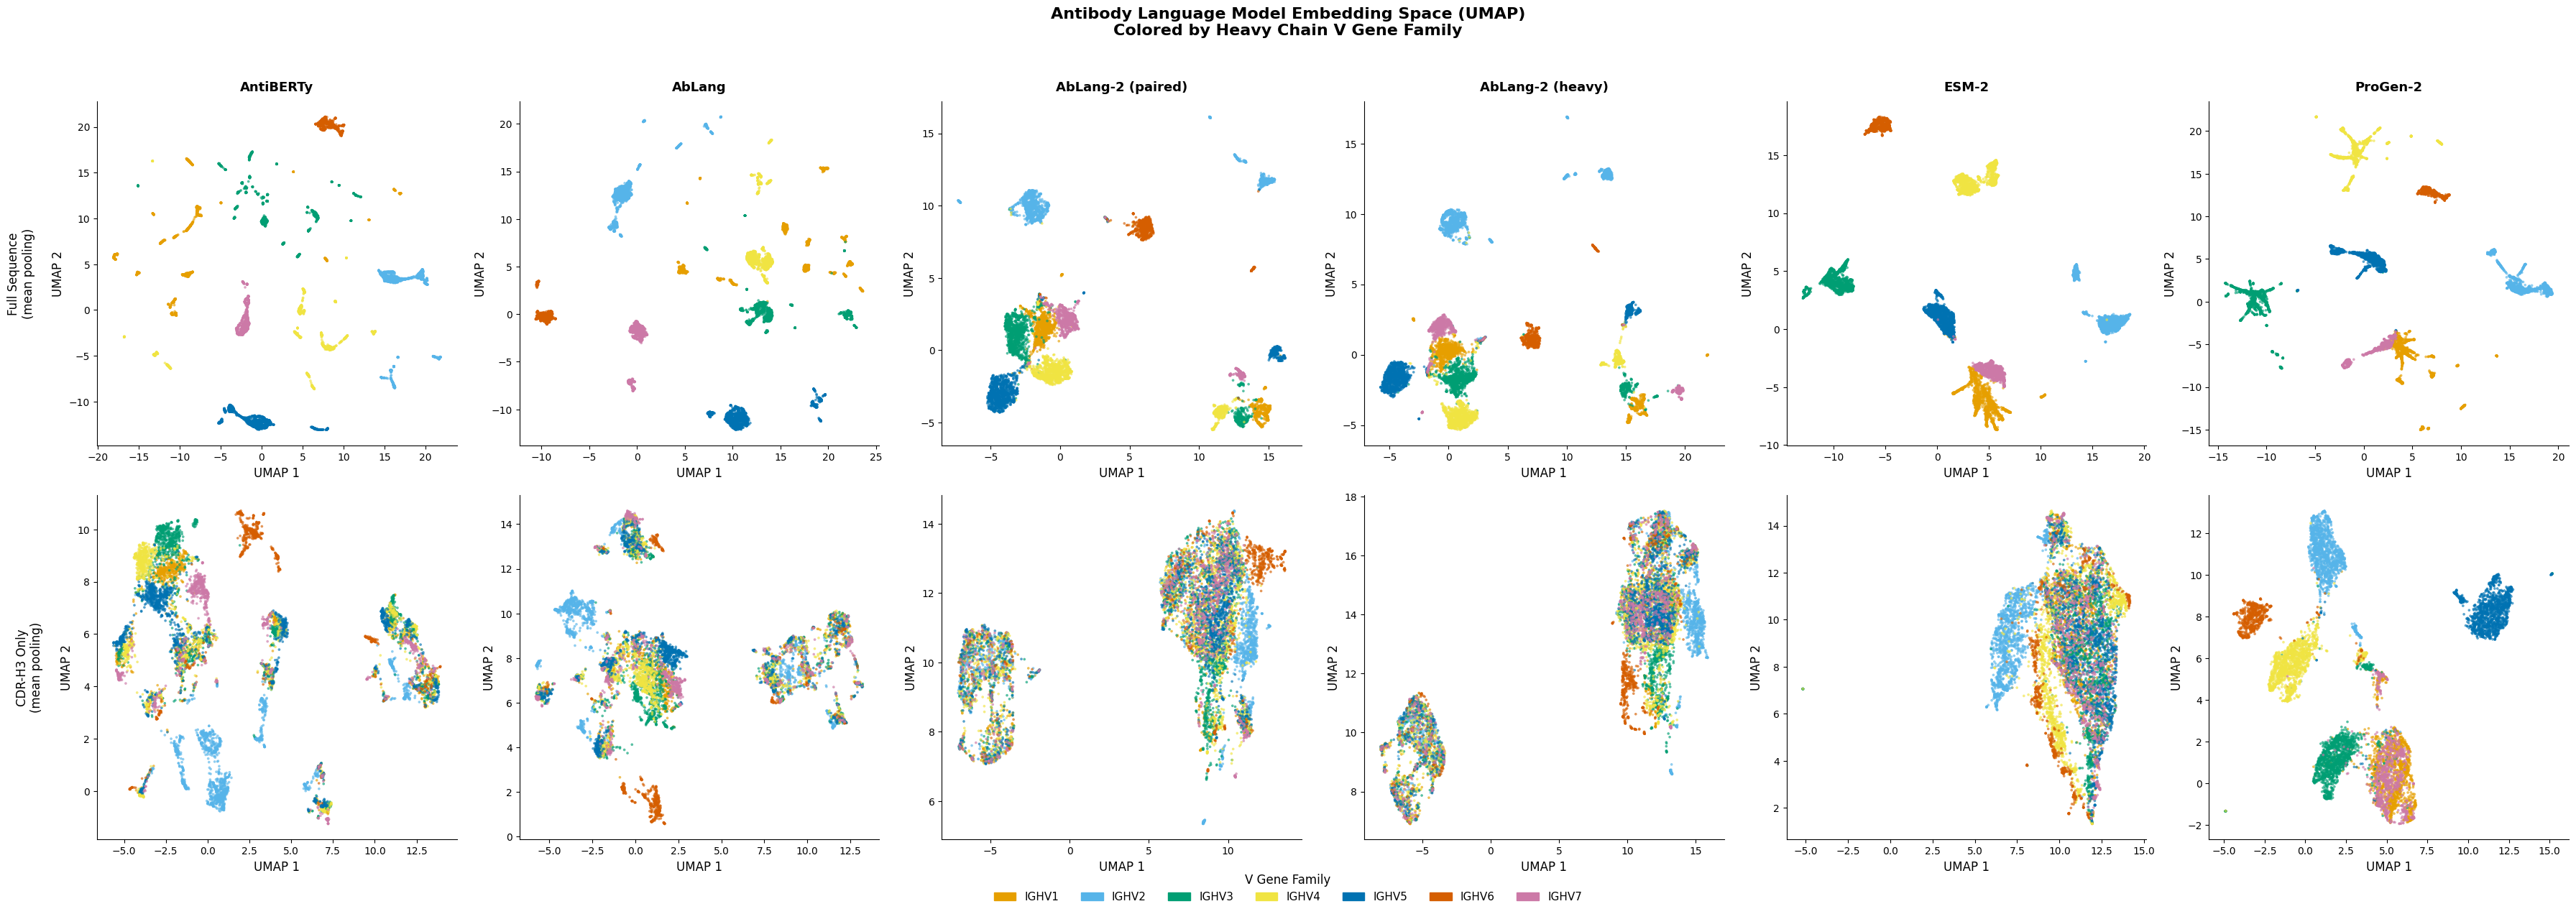

In [7]:
MODEL_NAMES = ["AntiBERTy", "AbLang", "AbLang-2 (paired)", "AbLang-2 (heavy)", "ESM-2", "ProGen-2"]
LEVELS      = ["Sequence", "CDR-H3"]
ROW_LABELS  = ["Full Sequence\n(mean pooling)", "CDR-H3 Only\n(mean pooling)"]


def scatter_umap(
    ax: plt.Axes,
    coords: np.ndarray,
    colors: list[str],
    alpha: float = 0.65,
    s: float = 7,
) -> None:
    ax.scatter(
        coords[:, 0], coords[:, 1],
        c=colors, s=s, alpha=alpha,
        linewidths=0, rasterized=True,
    )
    ax.set_xlabel("UMAP 1", fontsize=12)
    ax.set_ylabel("UMAP 2", fontsize=12)
    ax.tick_params(labelsize=10)


fig, axes = plt.subplots(2, 6, figsize=(36, 12), facecolor="white")
fig.suptitle(
    "Antibody Language Model Embedding Space (UMAP)\n"
    "Colored by Heavy Chain V Gene Family",
    fontsize=16, fontweight="bold", y=1.02,
)

for row_idx, level in enumerate(LEVELS):
    for col_idx, model_name in enumerate(MODEL_NAMES):
        ax = axes[row_idx, col_idx]
        scatter_umap(ax, umap_coords[(model_name, level)], point_colors)

        if row_idx == 0:
            ax.set_title(model_name, fontsize=13, fontweight="bold", pad=10)
        if col_idx == 0:
            ax.set_ylabel(f"{ROW_LABELS[row_idx]}\n\nUMAP 2", fontsize=12)

fig.legend(
    handles=legend_handles,
    title="V Gene Family", title_fontsize=12, fontsize=11,
    loc="lower center", ncol=len(unique_families),
    bbox_to_anchor=(0.5, -0.03), frameon=False,
)
plt.tight_layout()

for ext in ("pdf", "png"):
    p = FIG_DIR / f"umap_all_models.{ext}"
    fig.savefig(p, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"保存: {p}")
plt.show()

## 5. 個別図の保存

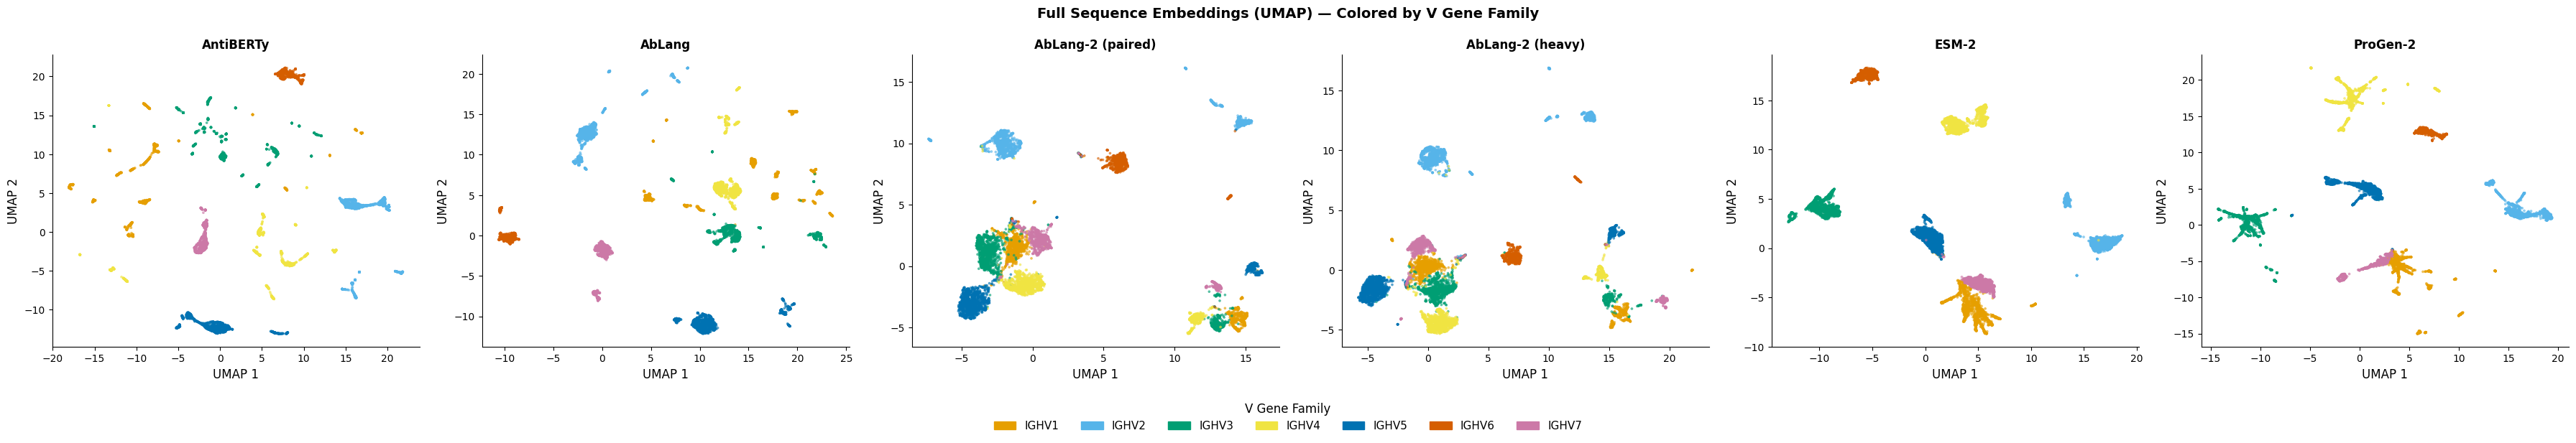

Sequence 図を保存しました


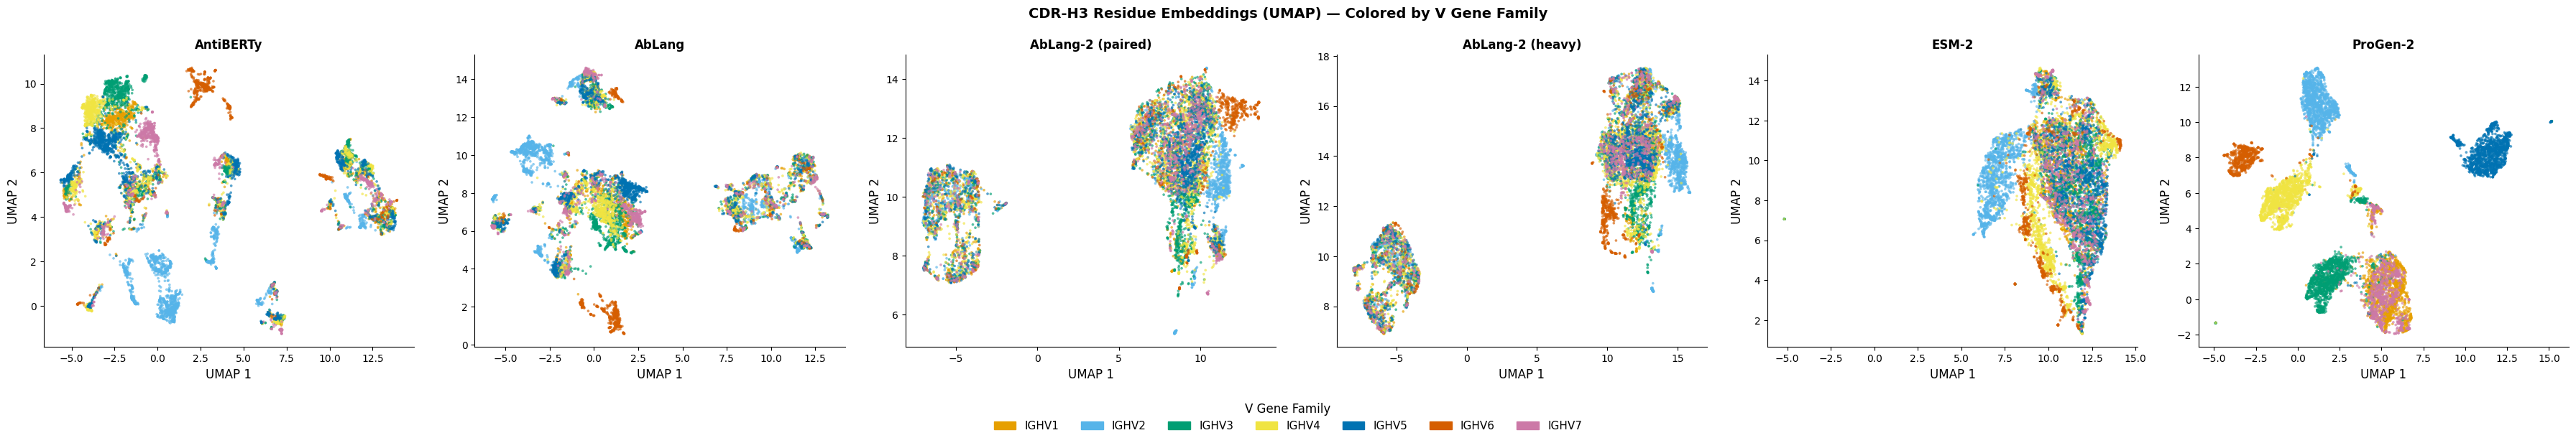

CDR-H3 図を保存しました

全図の保存完了


In [8]:
for level, fname_stem in [("Sequence", "umap_sequence_level"), ("CDR-H3", "umap_cdr3_level")]:
    title_map = {"Sequence": "Full Sequence Embeddings", "CDR-H3": "CDR-H3 Residue Embeddings"}
    fig_i, axes_i = plt.subplots(1, 6, figsize=(36, 5.5), facecolor="white")
    fig_i.suptitle(
        f"{title_map[level]} (UMAP) — Colored by V Gene Family",
        fontsize=14, fontweight="bold",
    )
    for col_idx, model_name in enumerate(MODEL_NAMES):
        ax = axes_i[col_idx]
        scatter_umap(ax, umap_coords[(model_name, level)], point_colors)
        ax.set_title(model_name, fontsize=12, fontweight="bold")

    fig_i.legend(
        handles=legend_handles,
        title="V Gene Family", title_fontsize=12, fontsize=11,
        loc="lower center", ncol=len(unique_families),
        bbox_to_anchor=(0.5, -0.12), frameon=False,
    )
    plt.tight_layout()
    for ext in ("pdf", "png"):
        p = FIG_DIR / f"{fname_stem}.{ext}"
        fig_i.savefig(p, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"{level} 図を保存しました")

print("\n全図の保存完了")

## 6. Pgen vs PLL 相関解析

OLGA (humanIGH) で計算した VDJ 生成確率 (Pgen) と、各言語モデルの疑似対数尤度 (PLL) の相関を可視化する。

- **図 1**: CDR3-specific PLL vs log10(Pgen_VJ) — 主要比較 (1×4)
- **図 2**: Full-seq PLL vs log10(Pgen_VJ) — 補足比較 (1×4)
- **図 3**: 統合図 (2×4)

事前に `scripts/03_compute_pgen_pll.py` の実行が必要です:
```bash
KMP_DUPLICATE_LIB_OK=TRUE mamba run -n ablm python scripts/03_compute_pgen_pll.py
```

In [9]:
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# pgen_pll_scores.csv を読み込む
scores_path = DATA_DIR / "pgen_pll_scores.csv"
if not scores_path.exists():
    raise FileNotFoundError(
        f"{scores_path} が見つかりません。"
        "scripts/03_compute_pgen_pll.py を実行してください。"
    )

df_scores = pd.read_csv(scores_path)
print(f"スコアファイル読み込み完了: {len(df_scores)} 行 × {len(df_scores.columns)} 列")
print(df_scores.describe().round(3))

# log10 Pgen (V/J 条件付き)
log10_pgen_vj = np.log10(df_scores["pgen_vj"].values.astype(float))

# V ファミリー色マッピング (UMAP セルで定義済みの family_color を再利用)
# ── ここで再計算 (スタンドアロン実行にも対応) ──
OKABE_ITO_7 = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442",
    "#0072B2", "#D55E00", "#CC79A7",
]
vf = df_scores["v_family"].tolist()
unique_fam = sorted(set(vf))
fam_color  = {f: OKABE_ITO_7[i % len(OKABE_ITO_7)] for i, f in enumerate(unique_fam)}
pt_colors  = [fam_color[f] for f in vf]
leg_handles = [
    mpatches.Patch(color=fam_color[f], label=f) for f in unique_fam
]

# 有効データマスク (log10_pgen が有限値の行)
valid_mask = np.isfinite(log10_pgen_vj)
print(f"有効 Pgen_VJ 件数: {valid_mask.sum()} / {len(df_scores)}")

# ── 治療用抗体データの読み込み ──
therapeutic_path = DATA_DIR / "therapeutic" / "pgen_pll_scores_therapeutic.csv"
has_therapeutic = therapeutic_path.exists()
if has_therapeutic:
    df_ther = pd.read_csv(therapeutic_path)
    log10_pgen_vj_ther = np.log10(df_ther["pgen_vj"].values.astype(float))
    valid_mask_ther = np.isfinite(log10_pgen_vj_ther)
    drug_names_ther = df_ther["drug_name"].tolist() if "drug_name" in df_ther.columns else None
    ther_handle = Line2D([0], [0], marker='*', color='none', markeredgecolor='black',
                         markerfacecolor='red', markersize=10, label='Therapeutic Ab', linewidth=0)
    print(f"治療用抗体: {len(df_ther)} 配列読み込み")
else:
    print("治療用抗体データなし (data/therapeutic/pgen_pll_scores_therapeutic.csv)")


スコアファイル読み込み完了: 8626 行 × 16 列
         pgen  pgen_vj  antiberty_pll  antiberty_cdr3_pll  ablang_pll  \
count  8617.0   8301.0       8626.000            8626.000    8626.000   
mean      0.0      0.0         -0.458              -1.745      -0.413   
std       0.0      0.0          0.218               0.500       0.219   
min       0.0      0.0         -1.353              -3.493      -1.452   
25%       0.0      0.0         -0.610              -2.095      -0.570   
50%       0.0      0.0         -0.459              -1.759      -0.420   
75%       0.0      0.0         -0.272              -1.405      -0.212   
max       0.0      0.0         -0.045              -0.101      -0.036   

       ablang_cdr3_pll  ablang2_paired_pll  ablang2_paired_cdr3_pll  \
count         8626.000            8626.000                 8626.000   
mean            -1.516              -0.461                   -1.492   
std              0.508               0.216                    0.469   
min             -3.420       

In [10]:
def plot_pgen_pll_panel(ax, x, y, colors, mask, xlabel, ylabel, title,
                        overlay_x=None, overlay_y=None, overlay_mask=None,
                        overlay_labels=None):
    """1 パネルの散布図を描画し、Spearman ρ を付記する。"""
    xv = x[mask]
    yv = y[mask]
    cv = [colors[i] for i in range(len(colors)) if mask[i]]

    # 有効値のさらなるフィルタ
    both_valid = np.isfinite(xv) & np.isfinite(yv)
    if both_valid.sum() == 0:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                ha="center", va="center", fontsize=11)
        ax.set_title(title)
        return

    xv, yv = xv[both_valid], yv[both_valid]
    cv = [cv[i] for i in range(len(cv)) if both_valid[i]]

    ax.scatter(xv, yv, c=cv, s=4, alpha=0.25, linewidths=0, rasterized=True)

    rho, pval = spearmanr(xv, yv)
    pval_str = f"p < 0.001" if pval < 0.001 else f"p = {pval:.3f}"
    ax.text(
        0.97, 0.96,
        f"ρ = {rho:.3f}\n{pval_str}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.85),
    )

    # 治療用抗体のオーバーレイ
    if overlay_x is not None and overlay_y is not None:
        omask = overlay_mask if overlay_mask is not None else np.ones(len(overlay_x), dtype=bool)
        ox, oy = overlay_x[omask], overlay_y[omask]
        ov = np.isfinite(ox) & np.isfinite(oy)
        if ov.sum() > 0:
            ax.scatter(ox[ov], oy[ov], marker='*', s=120, c='red',
                      edgecolors='black', linewidths=0.6, zorder=5, alpha=0.9)

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(labelsize=9)


MODEL_NAMES  = ["AntiBERTy", "AbLang", "AbLang-2 (paired)", "AbLang-2 (heavy)", "ESM-2", "ProGen-2"]
PLL_FULL_COLS = [
    "antiberty_pll", "ablang_pll",
    "ablang2_paired_pll", "ablang2_heavy_pll",
    "esm2_pll", "progen2_pll",
]
PLL_CDR3_COLS = [
    "antiberty_cdr3_pll", "ablang_cdr3_pll",
    "ablang2_paired_cdr3_pll", "ablang2_heavy_cdr3_pll",
    "esm2_cdr3_pll", "progen2_cdr3_pll",
]

KeyError: 'progen2_cdr3_pll'

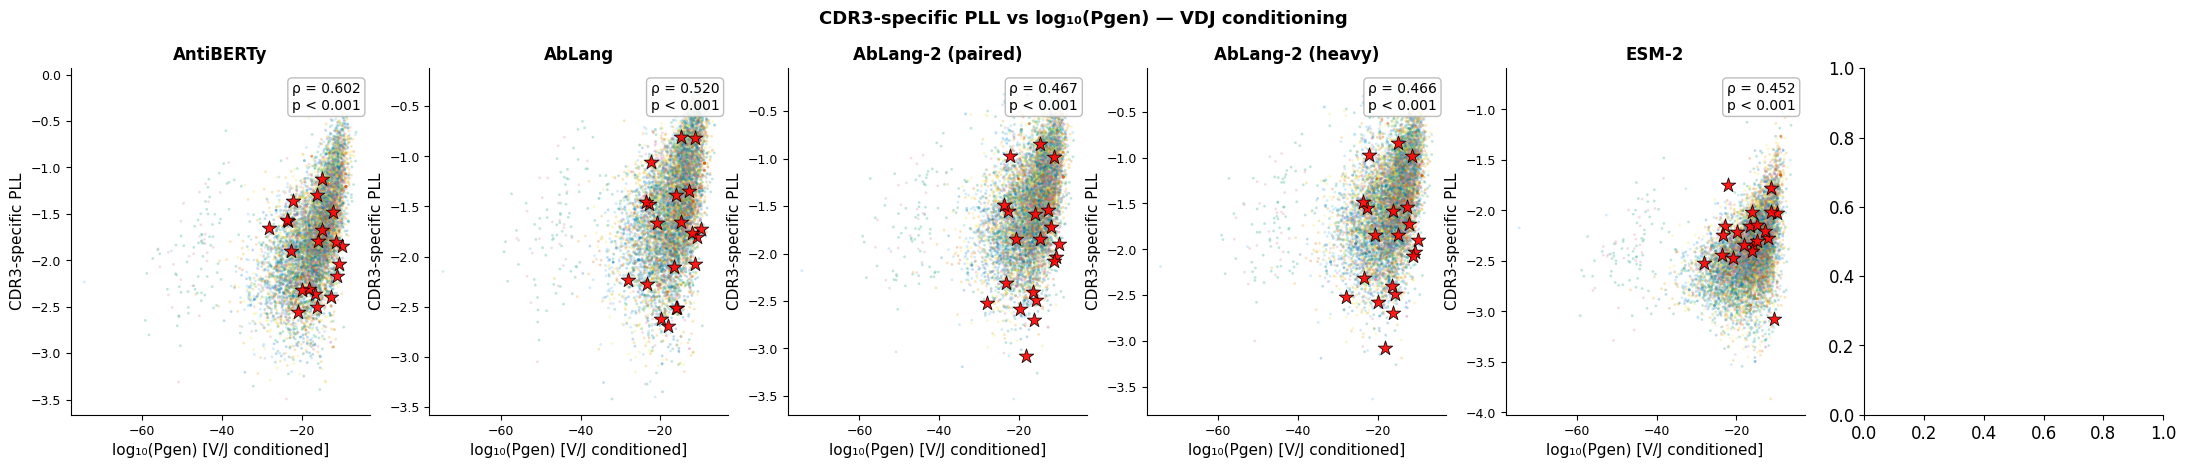

In [11]:
# 図 1: CDR3-specific PLL vs log10(Pgen_VJ)  (1×6)
fig, axes = plt.subplots(1, 6, figsize=(27, 4.5))
fig.suptitle(
    "CDR3-specific PLL vs log₁₀(Pgen) — VDJ conditioning",
    fontsize=13, fontweight="bold", y=1.01,
)

for ax, col, name in zip(axes, PLL_CDR3_COLS, MODEL_NAMES):
    y = df_scores[col].values.astype(float)
    ov_y = df_ther[col].values.astype(float) if has_therapeutic and col in df_ther.columns else None
    plot_pgen_pll_panel(
        ax=ax,
        x=log10_pgen_vj,
        y=y,
        colors=pt_colors,
        mask=valid_mask,
        xlabel="log₁₀(Pgen) [V/J conditioned]",
        ylabel="CDR3-specific PLL",
        title=name,
        overlay_x=log10_pgen_vj_ther if has_therapeutic else None,
        overlay_y=ov_y,
        overlay_mask=valid_mask_ther if has_therapeutic else None,
    )

# 凡例 (右外)
all_handles = leg_handles + ([ther_handle] if has_therapeutic else [])
fig.legend(
    handles=all_handles,
    title="V family",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=10,
    title_fontsize=11,
    framealpha=0.9,
)
fig.tight_layout()

for ext in ("png", "pdf"):
    out_path = FIG_DIR / f"pgen_vs_cdr3_pll.{ext}"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"保存: {out_path}")
plt.show()

In [ ]:
# 図 2: Full-seq PLL vs log10(Pgen_VJ)  (1×6)
fig, axes = plt.subplots(1, 6, figsize=(27, 4.5))
fig.suptitle(
    "Full-sequence PLL vs log₁₀(Pgen) — VDJ conditioning",
    fontsize=13, fontweight="bold", y=1.01,
)

for ax, col, name in zip(axes, PLL_FULL_COLS, MODEL_NAMES):
    y = df_scores[col].values.astype(float)
    ov_y = df_ther[col].values.astype(float) if has_therapeutic and col in df_ther.columns else None
    plot_pgen_pll_panel(
        ax=ax,
        x=log10_pgen_vj,
        y=y,
        colors=pt_colors,
        mask=valid_mask,
        xlabel="log₁₀(Pgen) [V/J conditioned]",
        ylabel="Full-seq PLL",
        title=name,
        overlay_x=log10_pgen_vj_ther if has_therapeutic else None,
        overlay_y=ov_y,
        overlay_mask=valid_mask_ther if has_therapeutic else None,
    )

all_handles = leg_handles + ([ther_handle] if has_therapeutic else [])
fig.legend(
    handles=all_handles,
    title="V family",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=10,
    title_fontsize=11,
    framealpha=0.9,
)
fig.tight_layout()

for ext in ("png", "pdf"):
    out_path = FIG_DIR / f"pgen_vs_fullseq_pll.{ext}"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"保存: {out_path}")
plt.show()

In [ ]:
# 図 3: 統合図 2×6 (行 1: CDR3-PLL, 行 2: Full-seq PLL)
fig, axes = plt.subplots(2, 6, figsize=(27, 9))
fig.suptitle(
    "PLL vs log₁₀(Pgen) [V/J conditioned]",
    fontsize=14, fontweight="bold", y=1.01,
)

row_labels = ["CDR3-specific PLL", "Full-seq PLL"]
all_pll_cols = [PLL_CDR3_COLS, PLL_FULL_COLS]

for row_idx, (pll_cols, row_label) in enumerate(zip(all_pll_cols, row_labels)):
    for col_idx, (col, name) in enumerate(zip(pll_cols, MODEL_NAMES)):
        ax = axes[row_idx, col_idx]
        y = df_scores[col].values.astype(float)
        ov_y = df_ther[col].values.astype(float) if has_therapeutic and col in df_ther.columns else None
        xlabel = "log₁₀(Pgen) [V/J cond.]" if row_idx == 1 else ""
        title  = name if row_idx == 0 else ""
        plot_pgen_pll_panel(
            ax=ax,
            x=log10_pgen_vj,
            y=y,
            colors=pt_colors,
            mask=valid_mask,
            xlabel=xlabel,
            ylabel=row_label,
            title=title,
            overlay_x=log10_pgen_vj_ther if has_therapeutic else None,
            overlay_y=ov_y,
            overlay_mask=valid_mask_ther if has_therapeutic else None,
        )
        if col_idx == 0:
            ax.set_ylabel(row_label, fontsize=11)

all_handles = leg_handles + ([ther_handle] if has_therapeutic else [])
fig.legend(
    handles=all_handles,
    title="V family",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=10,
    title_fontsize=11,
    framealpha=0.9,
)
fig.tight_layout()

for ext in ("png", "pdf"):
    out_path = FIG_DIR / f"pgen_vs_pll_all.{ext}"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"保存: {out_path}")
plt.show()